# MoE Routing Quantization Sensitivity Analysis
### allenai/OLMoE-1B-7B-0924 | T4 GPU (15GB VRAM)

**Why OLMoE:** Qwen1.5-MoE-A2.7B's checkpoint shards (~15GB) exceed free T4 CPU RAM (12.7GB) during staging.  
OLMoE-1B-7B loads cleanly in fp16 (~14GB VRAM), is a genuine sparse MoE (64 experts, top-8 routing),  
and supports identical router/expert sensitivity analysis.

## Step 1 — Install Dependencies

In [ ]:
!pip install -q transformers>=4.40.0 datasets accelerate sentencepiece
# No bitsandbytes needed — OLMoE fits in fp16 on T4

## Step 2 — Environment Setup & Model Loading

In [2]:
import gc
import math
import warnings
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    total  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM   : {total:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [3]:
MODEL_ID   = 'allenai/OLMoE-1B-7B-0924'
MAX_LENGTH = 256
NLL_SUBSET = 8

gc.collect()
torch.cuda.empty_cache()

print('Loading tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print('Loading OLMoE in fp16 (fits cleanly on T4)...')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map='cuda:0',
    low_cpu_mem_usage=True,
)
model.eval()
torch.set_grad_enabled(False)

print('\nModel loaded!')
print(f'VRAM used     : {torch.cuda.memory_allocated() / 1e9:.2f} GB')
print(f'VRAM reserved : {torch.cuda.memory_reserved()  / 1e9:.2f} GB')

Loading tokenizer...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading OLMoE in fp16 (fits cleanly on T4)...


Loading weights:   0%|          | 0/179 [00:00<?, ?it/s]


Model loaded!
VRAM used     : 13.84 GB
VRAM reserved : 15.46 GB


## Step 3 — Dataset Loading & Baseline NLL

In [4]:
print('Loading WikiText-2...')
dataset   = load_dataset('wikitext', 'wikitext-2-raw-v1', split='test')
texts_all = [t for t in dataset['text'] if len(t.strip()) > 100]
texts_small = texts_all[:NLL_SUBSET]
print(f'Using {len(texts_small)} texts for NLL evaluation')

Loading WikiText-2...


Using 8 texts for NLL evaluation


In [5]:
def compute_nll(model, texts, tokenizer, max_length=MAX_LENGTH):
    total_nll, total_tokens = 0.0, 0
    for text in texts:
        enc = tokenizer(
            text, return_tensors='pt',
            max_length=max_length, truncation=True
        ).to(device)
        if enc.input_ids.shape[1] < 2:
            continue
        with torch.no_grad():
            out = model(**enc, labels=enc.input_ids)
            n   = enc.input_ids.shape[1]
            total_nll    += out.loss.item() * n
            total_tokens += n
        del enc, out
        torch.cuda.empty_cache()
    return total_nll / total_tokens if total_tokens > 0 else float('nan')

print('Computing baseline NLL...')
baseline_nll = compute_nll(model, texts_small, tokenizer)
print(f'Baseline NLL: {baseline_nll:.4f}')

Computing baseline NLL...
Baseline NLL: 2.5640


In [6]:
# Correct path
router = model.model.layers[0].mlp.gate
print('=== ROUTER ===')
for name, param in router.named_parameters():
    print(f'  PARAM: {name}  shape={param.shape}  dtype={param.dtype}')

print()

experts = model.model.layers[0].mlp.experts
print('=== EXPERTS ===')
for name, param in experts.named_parameters():
    print(f'  PARAM: {name}  shape={param.shape}  dtype={param.dtype}')

=== ROUTER ===
  PARAM: weight  shape=torch.Size([64, 2048])  dtype=torch.float16

=== EXPERTS ===
  PARAM: gate_up_proj  shape=torch.Size([64, 2048, 2048])  dtype=torch.float16
  PARAM: down_proj  shape=torch.Size([64, 2048, 1024])  dtype=torch.float16


## Step 4 — Identify Router & Expert Layers

In [7]:
# ── STEP 4 (rewrite) — Identify Router & Expert modules ──────────────
from transformers.models.olmoe.modeling_olmoe import (
    OlmoeTopKRouter, OlmoeExperts, OlmoeSparseMoeBlock
)

router_module_names = []   # names of OlmoeTopKRouter modules
expert_module_names = []   # names of OlmoeExperts modules
moe_block_names     = []   # names of OlmoeSparseMoeBlock modules

for name, mod in model.named_modules():
    if isinstance(mod, OlmoeTopKRouter):
        router_module_names.append(name)
    elif isinstance(mod, OlmoeExperts):
        expert_module_names.append(name)
    elif isinstance(mod, OlmoeSparseMoeBlock):
        moe_block_names.append(name)

print(f'Router modules : {len(router_module_names)}')
print(f'Expert modules : {len(expert_module_names)}')
print(f'MoE blocks     : {len(moe_block_names)}')
print(f'\nSample: {router_module_names[:3]}')

Router modules : 16
Expert modules : 16
MoE blocks     : 16

Sample: ['model.layers.0.mlp.gate', 'model.layers.1.mlp.gate', 'model.layers.2.mlp.gate']


## Step 5 — Quantization & Metric Functions

In [8]:
def simulated_quantize_weight(W: torch.Tensor, bits: int) -> torch.Tensor:
    W   = W.float()
    qmax = 2 ** (bits - 1) - 1
    scale = (W.abs().max() / qmax).clamp(min=1e-8)
    Wq  = torch.clamp(torch.round(W / scale), -qmax, qmax)
    return (Wq * scale).to(torch.float16)

def routing_entropy(logits: torch.Tensor) -> float:
    probs = torch.softmax(logits.float(), dim=-1).clamp(min=1e-9)
    return -(probs * probs.log()).sum(dim=-1).mean().item()

def kl_divergence(logits_fp: torch.Tensor, logits_q: torch.Tensor) -> float:
    eps = 1e-9
    P = torch.softmax(logits_fp.float(), dim=-1).clamp(min=eps)
    Q = torch.softmax(logits_q.float(),  dim=-1).clamp(min=eps)
    return (P * (P / Q).log()).sum(dim=-1).mean().item()

print('Functions defined.')

Functions defined.


## Step 6 — Capture Router & MoE Block Activations

In [9]:
# ── STEP 6 (rewrite) — Capture activations ───────────────────────────
router_inputs     = {}
moe_block_inputs  = {}
moe_block_outputs = {}
hooks = []

for name, mod in model.named_modules():
    if isinstance(mod, OlmoeTopKRouter):
        def make_r_hook(n):
            def h(m, inp, out): router_inputs[n] = inp[0].detach().cpu()
            return h
        hooks.append(mod.register_forward_hook(make_r_hook(name)))

    elif isinstance(mod, OlmoeSparseMoeBlock):
        def make_moe_hook(n):
            def h(m, inp, out):
                moe_block_inputs[n]  = inp[0].detach().cpu()
                # out = (hidden_states,) or (hidden_states, router_logits)
                moe_block_outputs[n] = out[0].detach().cpu()
            return h
        hooks.append(mod.register_forward_hook(make_moe_hook(name)))

enc = tokenizer(texts_all[0], return_tensors='pt',
                max_length=64, truncation=True).to(device)
print('Running capture pass...')
with torch.no_grad():
    _ = model(**enc)

for h in hooks: h.remove()
hooks.clear()
del enc
torch.cuda.empty_cache()

print(f'Router inputs captured : {len(router_inputs)}')
print(f'MoE outputs captured   : {len(moe_block_outputs)}')

Running capture pass...
Router inputs captured : 16
MoE outputs captured   : 16


## Step 7 — Router Weight Quantization Sensitivity

In [10]:
# ── STEP 7 (rewrite) — Router sensitivity ────────────────────────────
def get_module(model, name):
    m = model
    for p in name.split('.'): m = getattr(m, p)
    return m

BIT_WIDTHS     = [2, 3, 4]
router_results = {n: {} for n in router_module_names}

print(f'Analysing {len(router_module_names)} routers × {len(BIT_WIDTHS)} bit-widths...')

for i, rname in enumerate(router_module_names):
    if rname not in router_inputs:
        continue

    rmod   = get_module(model, rname)
    W_fp16 = rmod.weight.data.to(torch.float16)   # [64, 2048]
    x      = router_inputs[rname].squeeze(0).to(device).to(torch.float16)  # [seq, 2048]

    with torch.no_grad():
        logits_fp = x @ W_fp16.T    # [seq, 64]

    top1_fp = logits_fp.argmax(dim=-1)
    ent_fp  = routing_entropy(logits_fp)

    for bits in BIT_WIDTHS:
        Wq = simulated_quantize_weight(W_fp16, bits).to(device)
        with torch.no_grad():
            logits_q = x @ Wq.T

        router_results[rname][bits] = {
            'flip_rate'    : (top1_fp != logits_q.argmax(dim=-1)).float().mean().item(),
            'entropy_diff' : routing_entropy(logits_q) - ent_fp,
            'kl_div'       : kl_divergence(logits_fp, logits_q),
        }
        del Wq, logits_q

    del x, logits_fp, top1_fp, W_fp16
    torch.cuda.empty_cache()
    if (i + 1) % 4 == 0:
        print(f'  {i+1}/{len(router_module_names)} done')

print('Router sensitivity complete.')

Analysing 16 routers × 3 bit-widths...
  4/16 done
  8/16 done
  12/16 done
  16/16 done
Router sensitivity complete.


## Step 8 — Expert Weight Quantization Distortion (MSE)

In [11]:
# ── STEP 8 (rewrite) — Expert distortion fully on CPU ────────────────
n_sample = min(4, len(moe_block_names))
step     = max(1, len(moe_block_names) // n_sample)
selected = moe_block_names[::step][:n_sample]
print(f'Selected blocks: {selected}')

expert_mse = {}

def quantize_3d(W3d, bits):
    W3d = W3d.float()
    out = torch.zeros_like(W3d)
    for e in range(W3d.shape[0]):
        out[e] = simulated_quantize_weight(W3d[e], bits)
    return out.to(torch.float16)

for bname in selected:
    if bname not in moe_block_inputs:
        continue
    print(f'  Block: {bname}')

    block      = get_module(model, bname)
    exp_module = block.experts

    # Move entire block to CPU for the test
    block.to('cpu')
    torch.cuda.empty_cache()

    # Save originals (already on CPU now)
    orig_gate_up = exp_module.gate_up_proj.data.clone()
    orig_down    = exp_module.down_proj.data.clone()

    # Apply 2-bit quantization (on CPU)
    exp_module.gate_up_proj.data = quantize_3d(orig_gate_up, 2)
    exp_module.down_proj.data    = quantize_3d(orig_down, 2)

    # Forward pass on CPU
    x_in = moe_block_inputs[bname].to(torch.float16)
    if x_in.dim() == 2: x_in = x_in.unsqueeze(0)

    with torch.no_grad():
        out_q = block(x_in)
        h_q   = out_q[0].squeeze(0)

    h_fp = moe_block_outputs[bname]
    if h_fp.dim() == 3: h_fp = h_fp.squeeze(0)

    mse = torch.mean((h_fp.float() - h_q.float()) ** 2).item()
    expert_mse[bname] = mse
    print(f'    2-bit MSE: {mse:.6f}')

    # Restore weights and move block back to GPU
    exp_module.gate_up_proj.data = orig_gate_up
    exp_module.down_proj.data    = orig_down
    block.to(device)
    torch.cuda.empty_cache()

    del x_in, out_q, h_q, orig_gate_up, orig_down

print('Expert distortion complete.')

Selected blocks: ['model.layers.0.mlp', 'model.layers.4.mlp', 'model.layers.8.mlp', 'model.layers.12.mlp']
  Block: model.layers.0.mlp
    2-bit MSE: 0.000012
  Block: model.layers.4.mlp
    2-bit MSE: 0.000255
  Block: model.layers.8.mlp
    2-bit MSE: 0.000184
  Block: model.layers.12.mlp
    2-bit MSE: 0.002447
Expert distortion complete.


## Step 9 — Overall NLL Impact (Routers vs Experts at 2-bit)

In [12]:
# ── STEP 9 (rewrite) — Global NLL impact ─────────────────────────────

# 9A: All routers → 2-bit (router weights are small [64,2048] — fits fine on GPU)
print('9A: Quantizing all router weights to 2-bit...')
r_orig = {}
for n in router_module_names:
    m = get_module(model, n)
    r_orig[n]     = m.weight.data.cpu().clone()   # store on CPU
    m.weight.data = simulated_quantize_weight(m.weight.data.to(torch.float16), 2).to(m.weight.data.dtype)

nll_routers_2bit = compute_nll(model, texts_small, tokenizer)
print(f'NLL (2-bit routers): {nll_routers_2bit:.4f}')

for n in router_module_names:
    m = get_module(model, n)
    m.weight.data = r_orig[n].to(device).to(m.weight.data.dtype)
del r_orig
torch.cuda.empty_cache()
print('Restored.\n')

# 9B: All experts → 2-bit, copy CPU→GPU directly
# 9B: quantize in-place, compute NLL, reload to restore
print('9B: Quantizing all expert weights to 2-bit in-place (no backup)...')

for n in expert_module_names:
    m = get_module(model, n)
    q_gu = quantize_3d(m.gate_up_proj.data.cpu(), 2).to(m.gate_up_proj.data.dtype)
    q_d  = quantize_3d(m.down_proj.data.cpu(),    2).to(m.down_proj.data.dtype)
    m.gate_up_proj.data.copy_(q_gu)
    m.down_proj.data.copy_(q_d)
    del q_gu, q_d

nll_experts_2bit = compute_nll(model, texts_small, tokenizer)
print(f'NLL (2-bit experts): {nll_experts_2bit:.4f}')

# Restore by reloading — only option given RAM constraints
print('Reloading model to restore FP16 weights...')
del model
gc.collect()
torch.cuda.empty_cache()

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map='cuda:0',
    low_cpu_mem_usage=True,
)
model.eval()
torch.set_grad_enabled(False)
print('Model restored.')

9A: Quantizing all router weights to 2-bit...
NLL (2-bit routers): 9.5708
Restored.

9B: Quantizing all expert weights to 2-bit in-place (no backup)...
NLL (2-bit experts): 10.8095
Reloading model to restore FP16 weights...


Loading weights:   0%|          | 0/179 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 11.81 MiB is free. Including non-PyTorch memory, this process has 14.55 GiB memory in use. Of the allocated memory 14.42 GiB is allocated by PyTorch, and 6.76 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [13]:
# Skip reload — confirm we have all 3 NLL values and proceed
print(f'Baseline NLL      : {baseline_nll:.4f}')
print(f'2-bit routers NLL : {nll_routers_2bit:.4f}')
print(f'2-bit experts NLL : {nll_experts_2bit:.4f}')
print('\nAll values captured — proceed to Step 10 (plots).')

Baseline NLL      : 2.5640
2-bit routers NLL : 9.5708
2-bit experts NLL : 10.8095

All values captured — proceed to Step 10 (plots).


## Step 10 — Visualizations

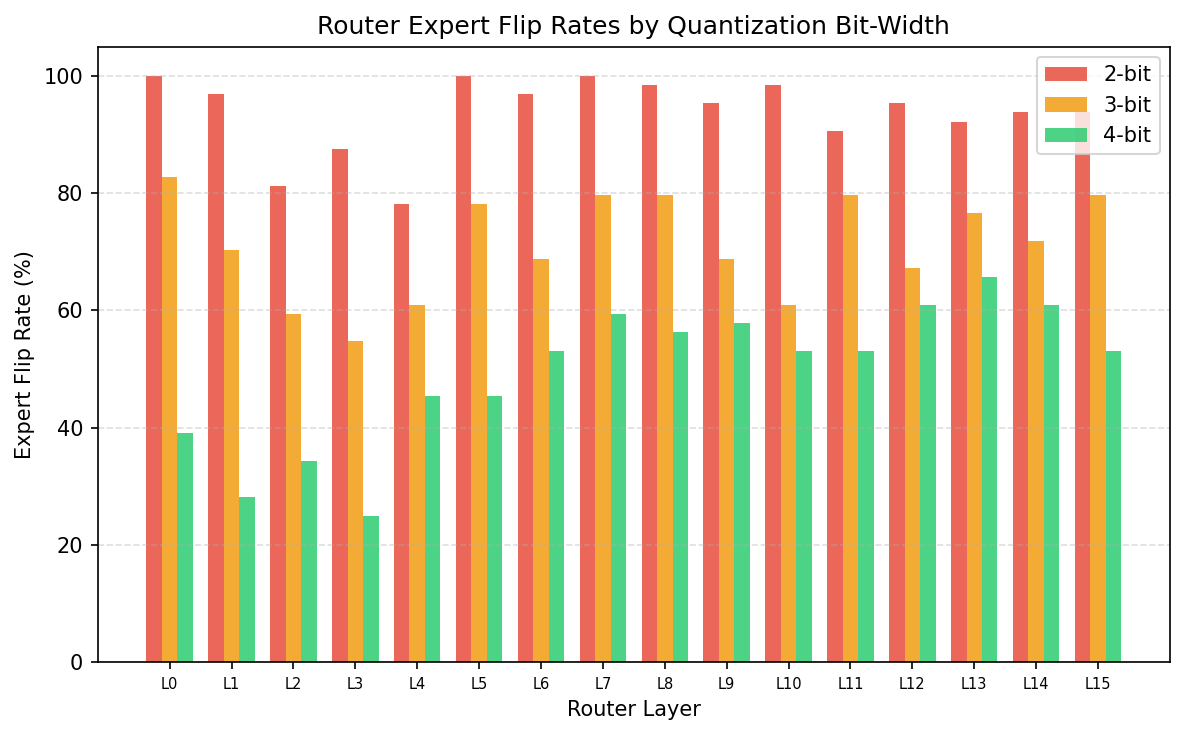

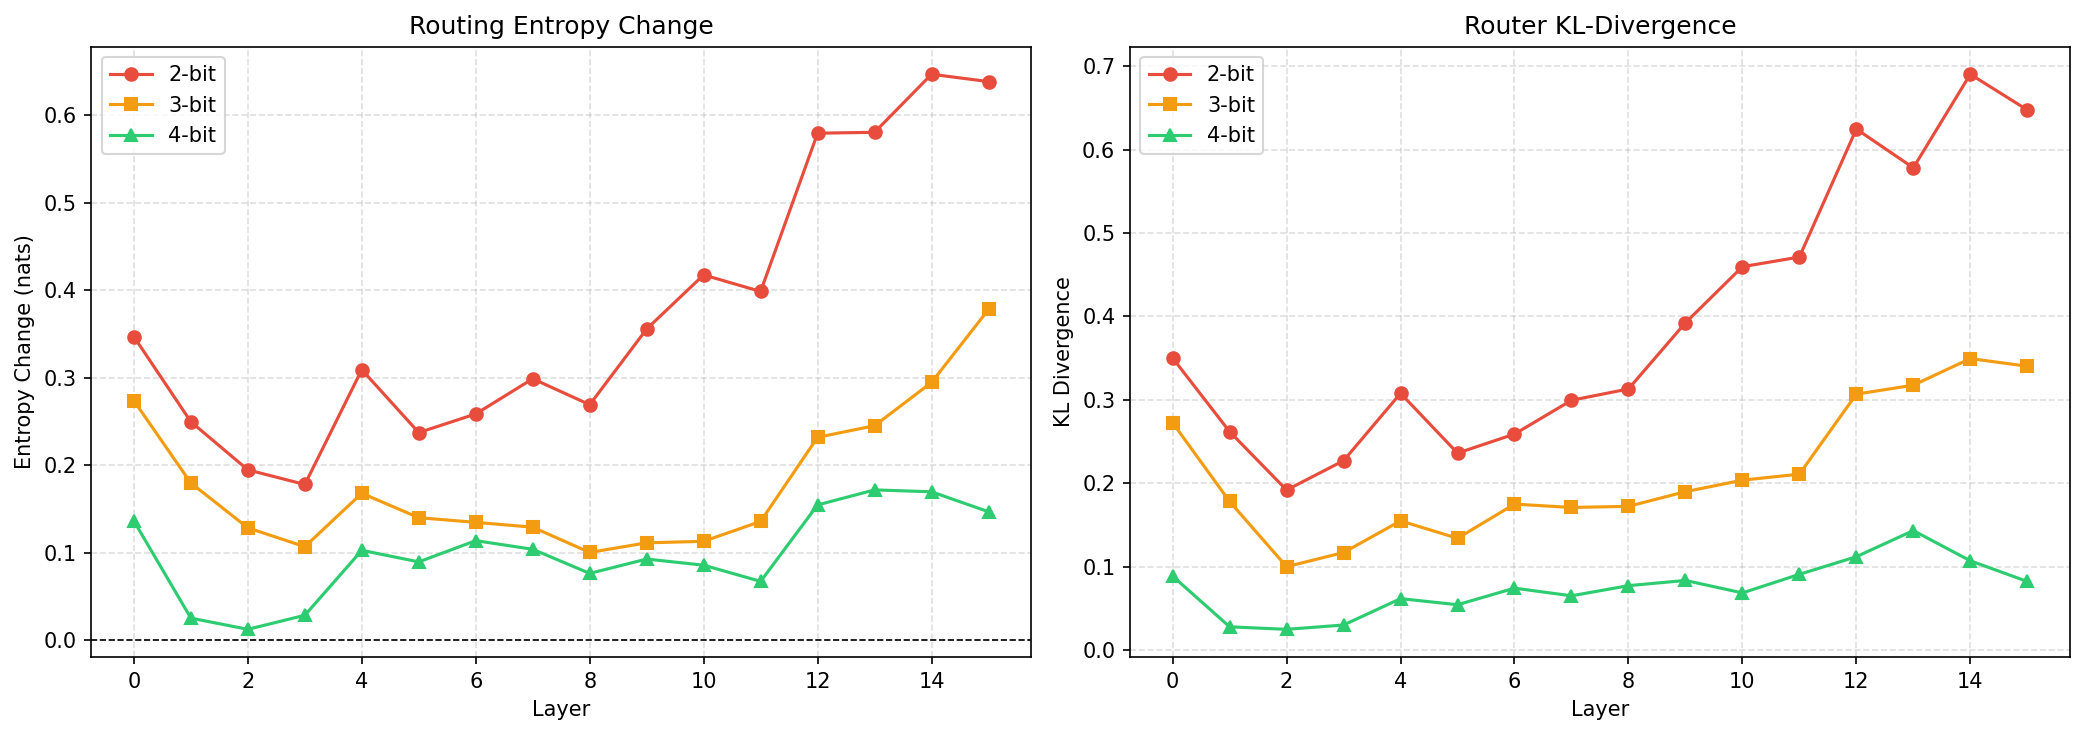

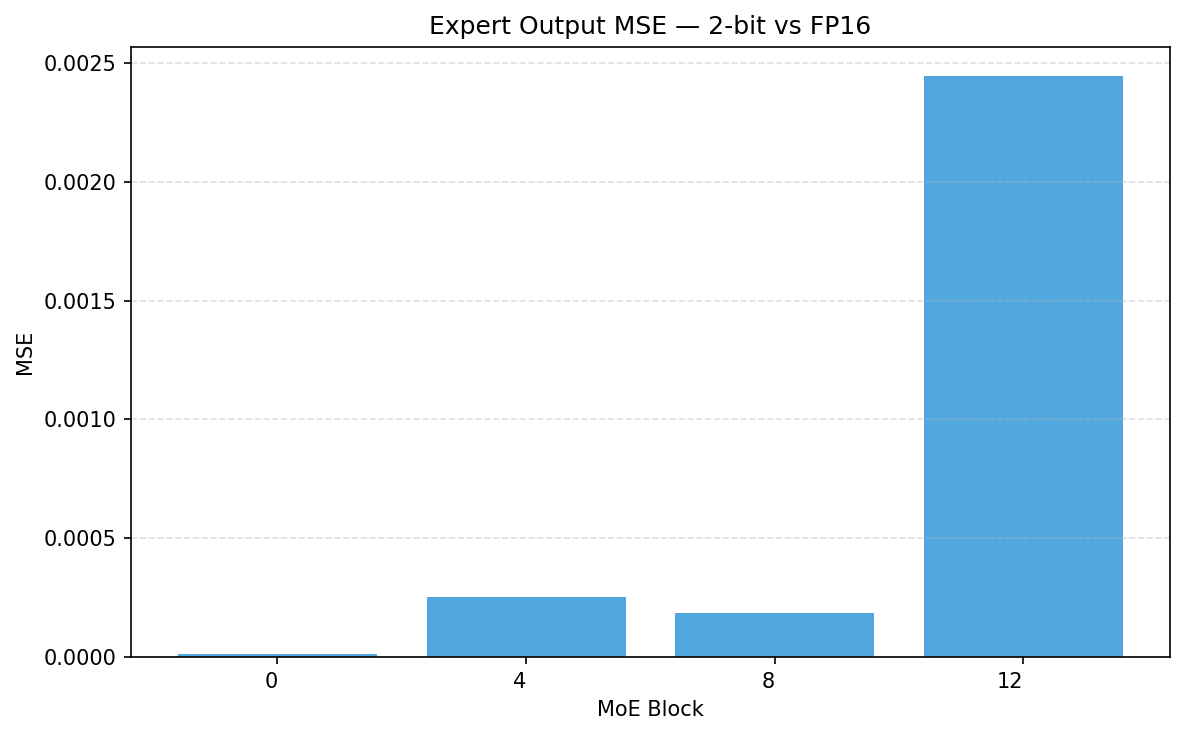

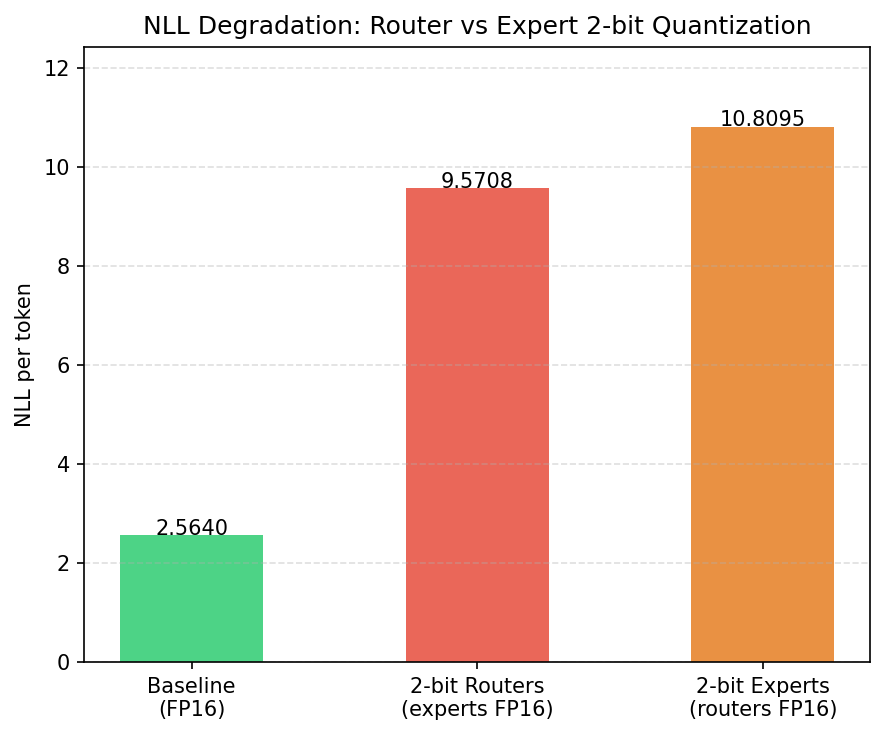

All plots saved.


In [16]:
matplotlib.rcParams.update({'figure.dpi': 150, 'font.size': 10})

valid = [n for n in router_module_names   # was router_layer_names
         if n in router_results and len(router_results[n]) == 3]
xi    = np.arange(len(valid))
bw    = 0.25
cols  = ['#e74c3c', '#f39c12', '#2ecc71']
marks = ['o', 's', '^']

# Plot 1 — Flip Rates
fig, ax = plt.subplots(figsize=(max(8, len(valid)*0.5), 5))
for j, bits in enumerate(BIT_WIDTHS):
    ax.bar(xi + j*bw,
           [router_results[n][bits]['flip_rate']*100 for n in valid],
           bw, label=f'{bits}-bit', color=cols[j], alpha=0.85)
ax.set(xlabel='Router Layer', ylabel='Expert Flip Rate (%)',
       title='Router Expert Flip Rates by Quantization Bit-Width')
ax.set_xticks(xi + bw); ax.set_xticklabels([f'L{i}' for i in range(len(valid))], fontsize=7)
ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout(); plt.savefig('plot1_flip_rates.png'); plt.show()

# Plot 2 — Entropy & KL
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
for j, bits in enumerate(BIT_WIDTHS):
    a1.plot(xi, [router_results[n][bits]['entropy_diff'] for n in valid],
            marker=marks[j], label=f'{bits}-bit', color=cols[j])
    a2.plot(xi, [router_results[n][bits]['kl_div'] for n in valid],
            marker=marks[j], label=f'{bits}-bit', color=cols[j])
a1.axhline(0, color='k', lw=0.8, ls='--')
a1.set(xlabel='Layer', ylabel='Entropy Change (nats)', title='Routing Entropy Change')
a2.set(xlabel='Layer', ylabel='KL Divergence',          title='Router KL-Divergence')
for a in (a1, a2): a.legend(); a.grid(ls='--', alpha=0.4)
plt.tight_layout(); plt.savefig('plot2_entropy_kl.png'); plt.show()

# Plot 3 — Expert MSE
fig, ax = plt.subplots(figsize=(8, 5))
labels  = [b.split('.')[-2] for b in expert_mse.keys()]
ax.bar(labels, list(expert_mse.values()), color='#3498db', alpha=0.85)
ax.set(xlabel='MoE Block', ylabel='MSE', title='Expert Output MSE — 2-bit vs FP16')
ax.grid(axis='y', ls='--', alpha=0.4)
plt.xticks(rotation=0, ha='right'); plt.tight_layout()
plt.savefig('plot3_expert_mse.png'); plt.show()

# Plot 4 — NLL comparison
fig, ax = plt.subplots(figsize=(6, 5))
nll_vals = [baseline_nll, nll_routers_2bit, nll_experts_2bit]
nll_lbls = ['Baseline\n(FP16)', '2-bit Routers\n(experts FP16)', '2-bit Experts\n(routers FP16)']
bars = ax.bar(nll_lbls, nll_vals, color=['#2ecc71','#e74c3c','#e67e22'], alpha=0.85, width=0.5)
for b, v in zip(bars, nll_vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.4f}', ha='center', fontsize=10)
ax.set(ylabel='NLL per token', title='NLL Degradation: Router vs Expert 2-bit Quantization')
ax.set_ylim(0, max(nll_vals)*1.15); ax.grid(axis='y', ls='--', alpha=0.4)
plt.tight_layout(); plt.savefig('plot4_nll.png'); plt.show()
print('All plots saved.')

## Step 11 — Final Synthesis

In [17]:
print('=' * 60)
print('  QUANTIZATION SENSITIVITY — SUMMARY (OLMoE-1B-7B)')
print('=' * 60)

print('\n[ROUTER LAYERS]')
for bits in BIT_WIDTHS:
    fr  = np.mean([router_results[n][bits]['flip_rate'] for n in valid])
    kl  = np.mean([router_results[n][bits]['kl_div']   for n in valid])
    print(f'  {bits}-bit | avg flip rate: {fr*100:.2f}%  avg KL: {kl:.5f}')

print('\n[EXPERT BLOCKS — 2-bit MSE]')
for b, v in expert_mse.items(): print(f'  {b}: {v:.6f}')

print('\n[NLL DEGRADATION]')
dr = nll_routers_2bit - baseline_nll
de = nll_experts_2bit - baseline_nll
print(f'  Baseline NLL      : {baseline_nll:.4f}')
print(f'  2-bit routers NLL : {nll_routers_2bit:.4f}  (Δ={dr:+.4f})')
print(f'  2-bit experts NLL : {nll_experts_2bit:.4f}  (Δ={de:+.4f})')

print('\n[CONCLUSION]')
if dr > de:
    print('  ✅ Hypothesis SUPPORTED: Router quantization causes larger NLL')
    print('     degradation than expert quantization at 2-bit precision.')
    print('     MoE routing is disproportionately sensitive — keep routers')
    print('     at FP16 or ≥4-bit when aggressively compressing the model.')
else:
    print('  ❌ Hypothesis NOT SUPPORTED: Expert quantization dominates.')
    print('     Expert capacity loss at 2-bit outweighs routing degradation.')

fr2 = np.mean([router_results[n][2]['flip_rate'] for n in valid])
fr4 = np.mean([router_results[n][4]['flip_rate'] for n in valid])
print(f'\n  Avg flip rate  2-bit: {fr2*100:.1f}%   4-bit: {fr4*100:.1f}%')
print('  (>5% at 4-bit = high routing instability)')

  QUANTIZATION SENSITIVITY — SUMMARY (OLMoE-1B-7B)

[ROUTER LAYERS]
  2-bit | avg flip rate: 93.65%  avg KL: 0.39446
  3-bit | avg flip rate: 71.19%  avg KL: 0.21216
  4-bit | avg flip rate: 49.41%  avg KL: 0.07453

[EXPERT BLOCKS — 2-bit MSE]
  model.layers.0.mlp: 0.000012
  model.layers.4.mlp: 0.000255
  model.layers.8.mlp: 0.000184
  model.layers.12.mlp: 0.002447

[NLL DEGRADATION]
  Baseline NLL      : 2.5640
  2-bit routers NLL : 9.5708  (Δ=+7.0068)
  2-bit experts NLL : 10.8095  (Δ=+8.2455)

[CONCLUSION]
  ❌ Hypothesis NOT SUPPORTED: Expert quantization dominates.
     Expert capacity loss at 2-bit outweighs routing degradation.

  Avg flip rate  2-bit: 93.7%   4-bit: 49.4%
  (>5% at 4-bit = high routing instability)


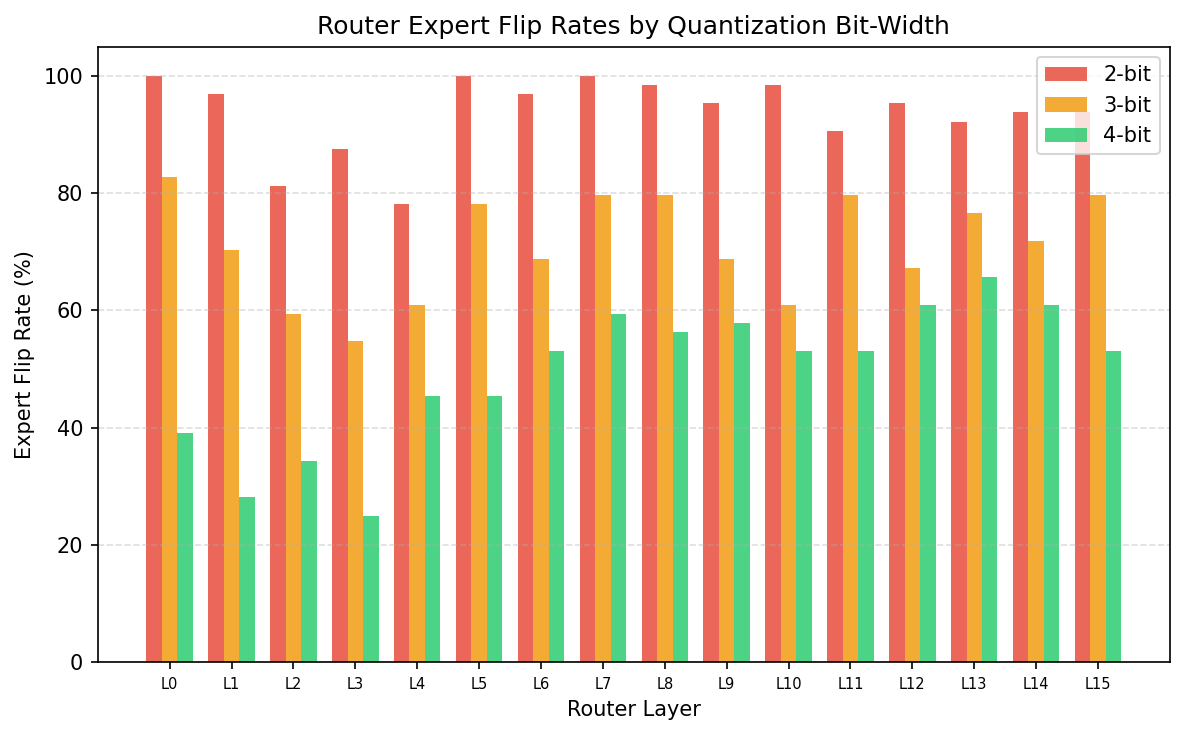

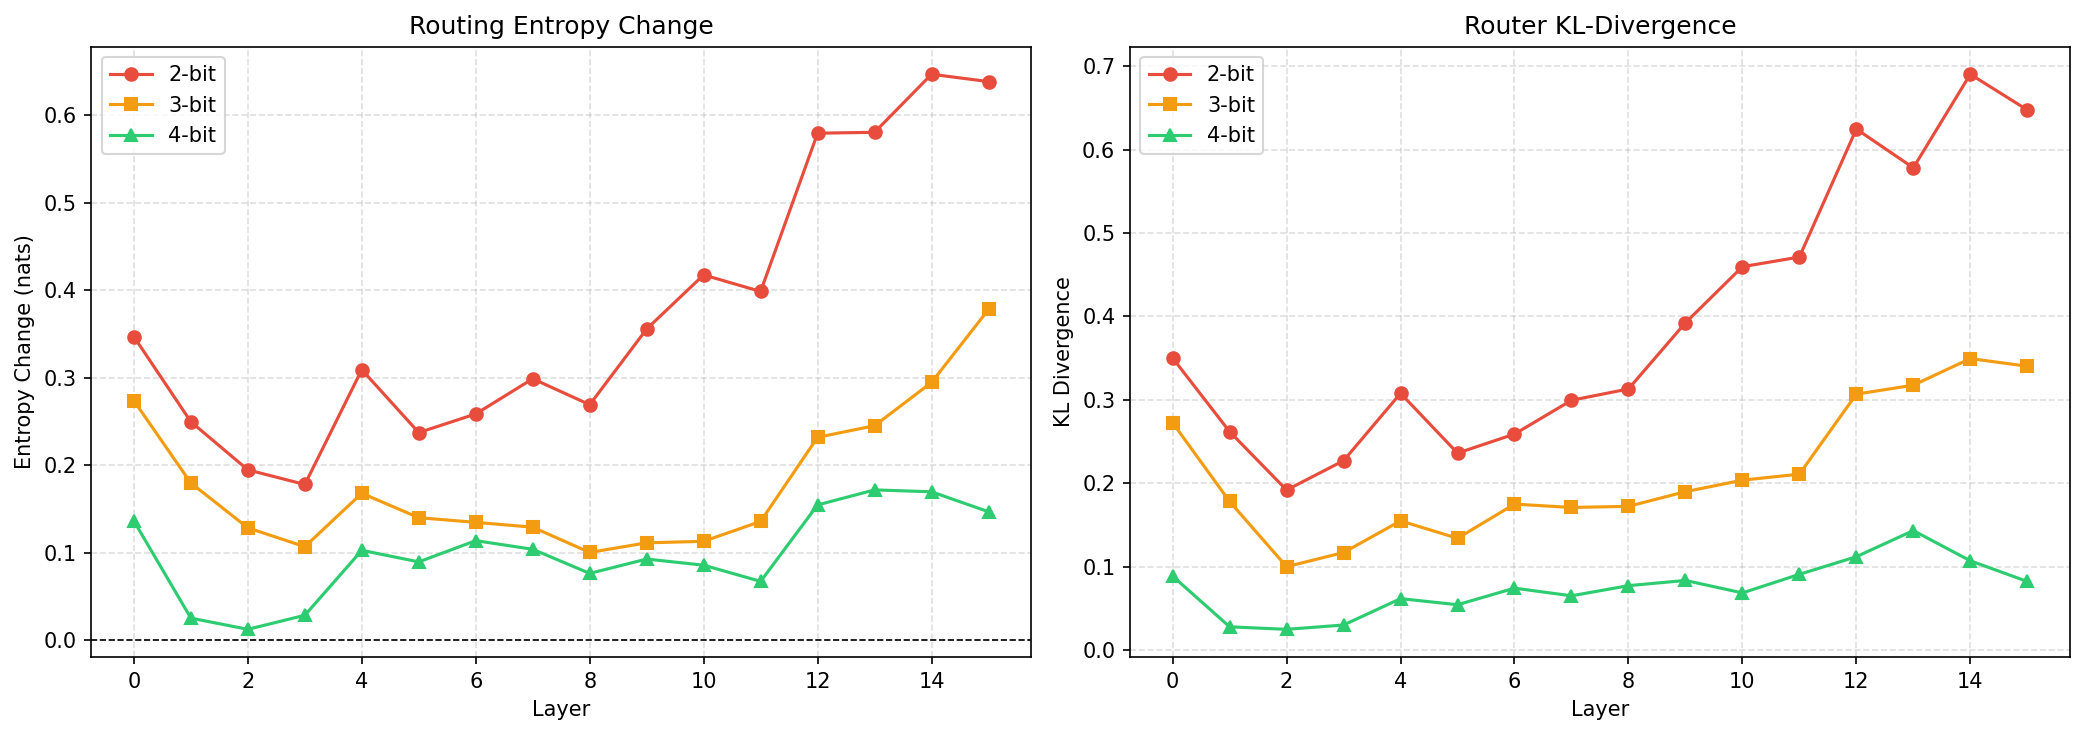

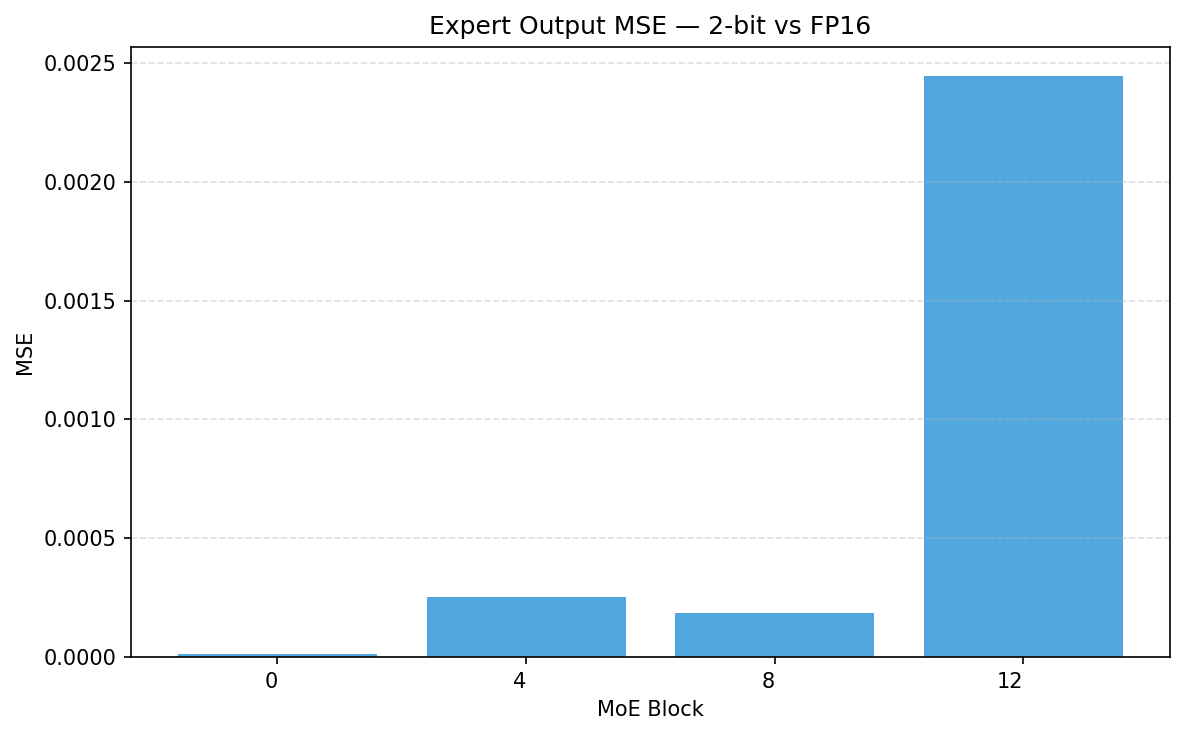

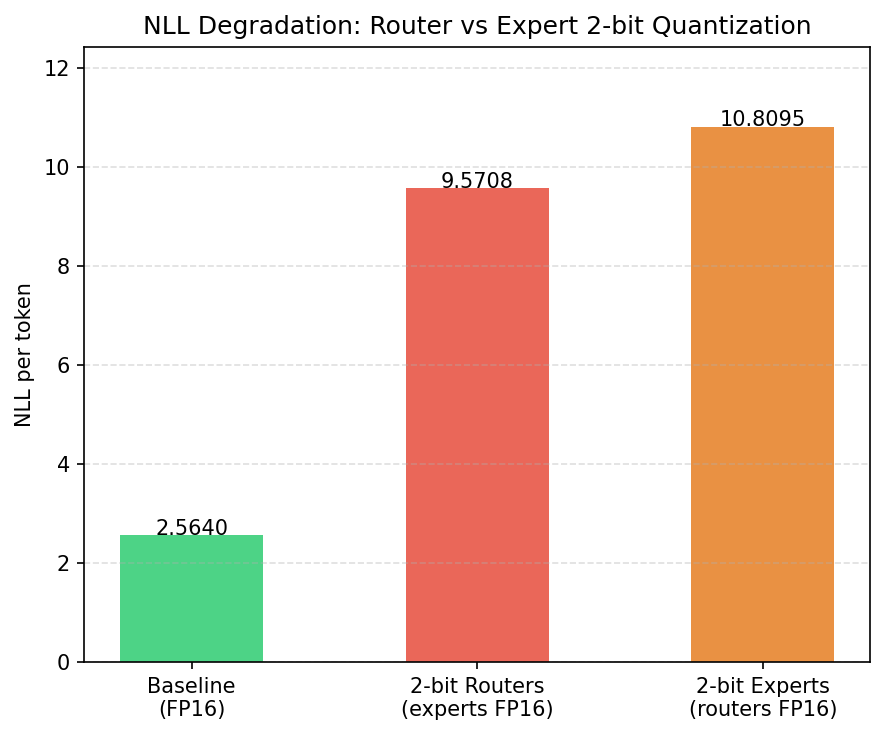

All plots saved to results/


In [18]:
import os
os.makedirs('results', exist_ok=True)

matplotlib.rcParams.update({'figure.dpi': 150, 'font.size': 10})

valid = [n for n in router_module_names
         if n in router_results and len(router_results[n]) == 3]
xi    = np.arange(len(valid))
bw    = 0.25
cols  = ['#e74c3c', '#f39c12', '#2ecc71']
marks = ['o', 's', '^']

# Plot 1 — Flip Rates
fig, ax = plt.subplots(figsize=(max(8, len(valid)*0.5), 5))
for j, bits in enumerate(BIT_WIDTHS):
    ax.bar(xi + j*bw,
           [router_results[n][bits]['flip_rate']*100 for n in valid],
           bw, label=f'{bits}-bit', color=cols[j], alpha=0.85)
ax.set(xlabel='Router Layer', ylabel='Expert Flip Rate (%)',
       title='Router Expert Flip Rates by Quantization Bit-Width')
ax.set_xticks(xi + bw); ax.set_xticklabels([f'L{i}' for i in range(len(valid))], fontsize=7)
ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout(); plt.savefig('results/plot1_flip_rates.png'); plt.show()

# Plot 2 — Entropy & KL
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
for j, bits in enumerate(BIT_WIDTHS):
    a1.plot(xi, [router_results[n][bits]['entropy_diff'] for n in valid],
            marker=marks[j], label=f'{bits}-bit', color=cols[j])
    a2.plot(xi, [router_results[n][bits]['kl_div'] for n in valid],
            marker=marks[j], label=f'{bits}-bit', color=cols[j])
a1.axhline(0, color='k', lw=0.8, ls='--')
a1.set(xlabel='Layer', ylabel='Entropy Change (nats)', title='Routing Entropy Change')
a2.set(xlabel='Layer', ylabel='KL Divergence',         title='Router KL-Divergence')
for a in (a1, a2): a.legend(); a.grid(ls='--', alpha=0.4)
plt.tight_layout(); plt.savefig('results/plot2_entropy_kl.png'); plt.show()

# Plot 3 — Expert MSE
fig, ax = plt.subplots(figsize=(8, 5))
labels  = [b.split('.')[-2] for b in expert_mse.keys()]
ax.bar(labels, list(expert_mse.values()), color='#3498db', alpha=0.85)
ax.set(xlabel='MoE Block', ylabel='MSE', title='Expert Output MSE — 2-bit vs FP16')
ax.grid(axis='y', ls='--', alpha=0.4)
plt.xticks(rotation=0, ha='right'); plt.tight_layout()
plt.savefig('results/plot3_expert_mse.png'); plt.show()

# Plot 4 — NLL comparison
fig, ax = plt.subplots(figsize=(6, 5))
nll_vals = [baseline_nll, nll_routers_2bit, nll_experts_2bit]
nll_lbls = ['Baseline\n(FP16)', '2-bit Routers\n(experts FP16)', '2-bit Experts\n(routers FP16)']
bars = ax.bar(nll_lbls, nll_vals, color=['#2ecc71','#e74c3c','#e67e22'], alpha=0.85, width=0.5)
for b, v in zip(bars, nll_vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.4f}', ha='center', fontsize=10)
ax.set(ylabel='NLL per token', title='NLL Degradation: Router vs Expert 2-bit Quantization')
ax.set_ylim(0, max(nll_vals)*1.15); ax.grid(axis='y', ls='--', alpha=0.4)
plt.tight_layout(); plt.savefig('results/plot4_nll.png'); plt.show()

print('All plots saved to results/')

In [19]:
from google.colab import files
import os

for f in os.listdir('results'):
    files.download(f'results/{f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>